# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|     Intifada Afkar Lazain Muhammad         |   5054251029|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

'''

data = pd.read_csv('namafile.csv')
data.head()
data.info()
data.describe()

! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

'''

data = pd.read_csv("WineQT.csv")
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [3]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


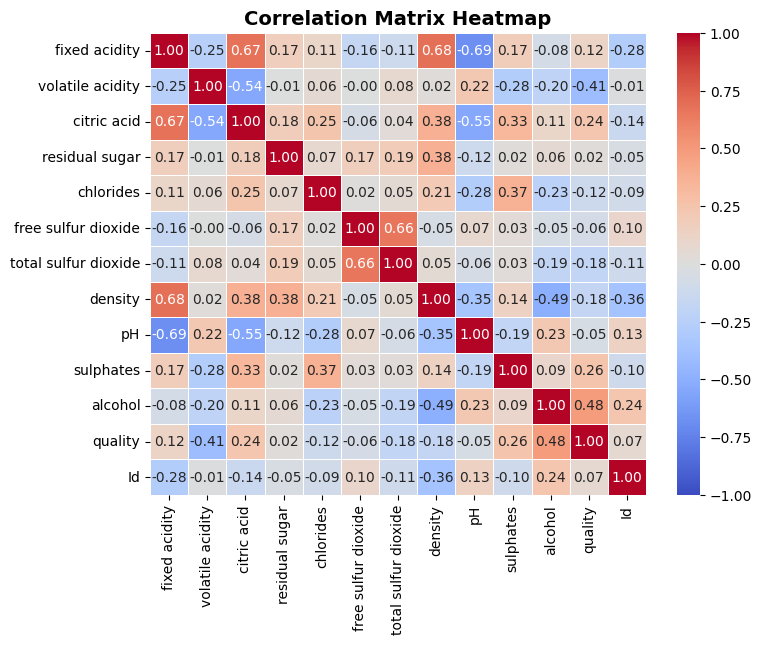

In [4]:
# Tampilkan Korelasi Matrix
corr_matrix = data.corr(method="pearson", numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',     
    vmin=-1, vmax=1,    
    fmt='.2f',           
    linewidths=0.5       
)

plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

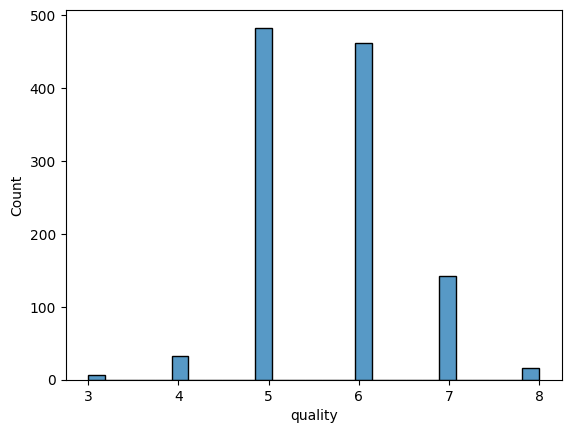

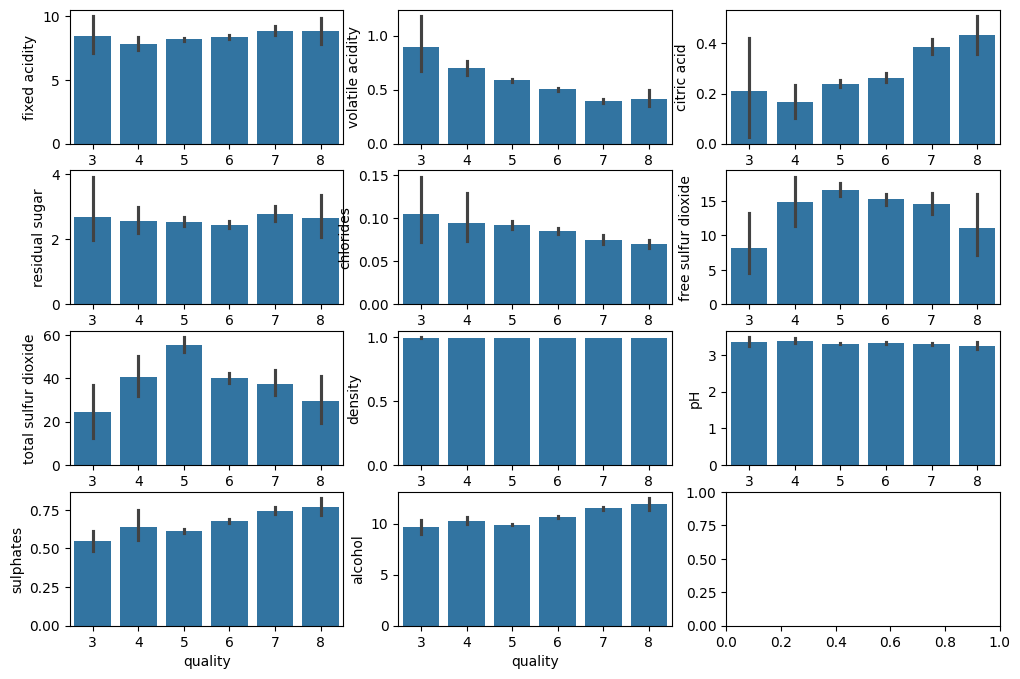

In [5]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

sns.histplot(data, x="quality")
plt.show()
cols = [c for c in data.columns if c != "quality" and c!= "Id"]
fig, ax = plt.subplots(nrows=11//3+1,ncols= 3,figsize=(12, 8))

n = 0
t=0
for Y in cols:
    sns.barplot(data, x="quality", y=Y, ax=ax[t,n])
    n += 1
    if n>=3:
        n=0
        t += 1
    # if t > 11:
    #     break
plt.show()

In [6]:
for Y in cols:
    print(Y)

fixed acidity
volatile acidity
citric acid
residual sugar
chlorides
free sulfur dioxide
total sulfur dioxide
density
pH
sulphates
alcohol


## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [7]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

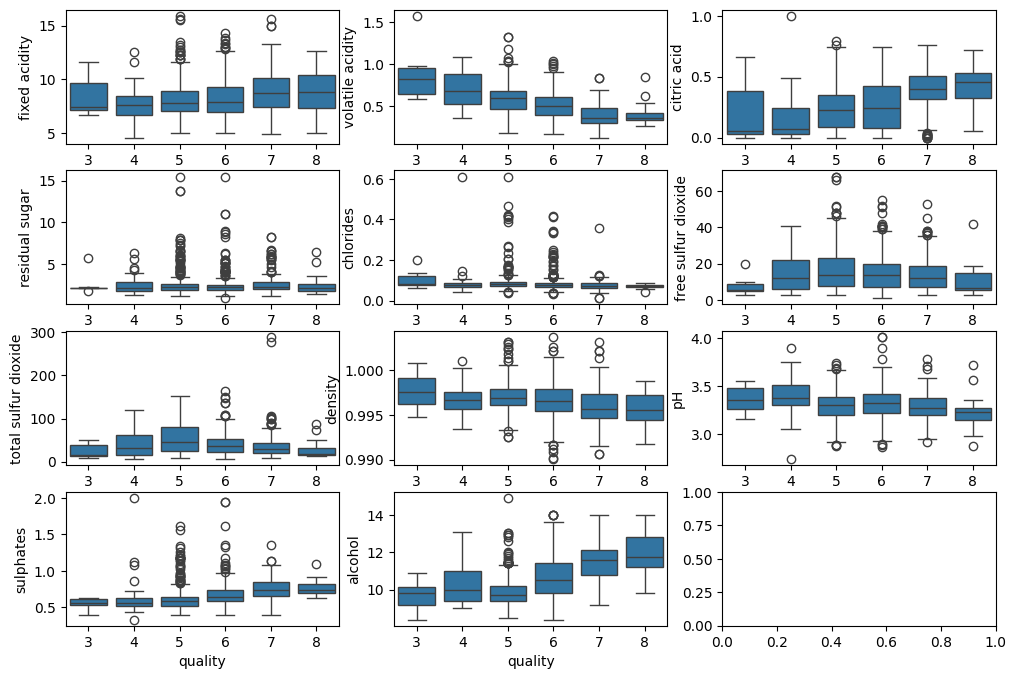

In [9]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
fig, ax = plt.subplots(nrows=11//3+1,ncols= 3,figsize=(12, 8))

n = 0
t=0
for Y in cols:
    sns.boxplot(data, x="quality", y=Y, ax=ax[t,n])
    n += 1
    if n>=3:
        n=0
        t += 1
    # if t > 11:
    #     break
plt.show()

In [10]:
Q1 = data['sulphates'].quantile(0.25)
Q3 = data['sulphates'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['sulphates'] < lower_bound) | (data['sulphates'] > upper_bound)]
print("Outliers:\n")
outliers



Outliers:



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
11,7.8,0.610,0.29,1.6,0.114,9.0,29.0,0.99740,3.26,1.56,9.1,5,13
13,7.9,0.320,0.51,1.8,0.341,17.0,56.0,0.99690,3.04,1.08,9.2,6,19
31,8.1,0.660,0.22,2.2,0.069,9.0,23.0,0.99680,3.30,1.20,10.3,5,43
54,8.3,0.625,0.20,1.5,0.080,27.0,119.0,0.99720,3.16,1.12,9.1,4,79
59,8.6,0.490,0.28,1.9,0.110,20.0,136.0,0.99720,2.93,1.95,9.9,6,86
61,9.3,0.390,0.44,2.1,0.107,34.0,125.0,0.99780,3.14,1.22,9.5,5,88
64,8.6,0.490,0.28,1.9,0.110,20.0,136.0,0.99720,2.93,1.95,9.9,6,91
75,7.8,0.410,0.68,1.7,0.467,18.0,69.0,0.99730,3.08,1.31,9.3,5,106
103,9.2,0.520,1.00,3.4,0.610,32.0,69.0,0.99960,2.74,2.00,9.4,4,151
112,7.6,0.680,0.02,1.3,0.072,9.0,20.0,0.99650,3.17,1.08,9.2,4,161


In [11]:
Data_Outlier_Capped = data.copy()
for x in cols:
    Q1 =  Data_Outlier_Capped[x].quantile(0.25)
    Q3 =  Data_Outlier_Capped[x].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    Data_Outlier_Capped[x] = np.clip( Data_Outlier_Capped[x], lower_bound, upper_bound)



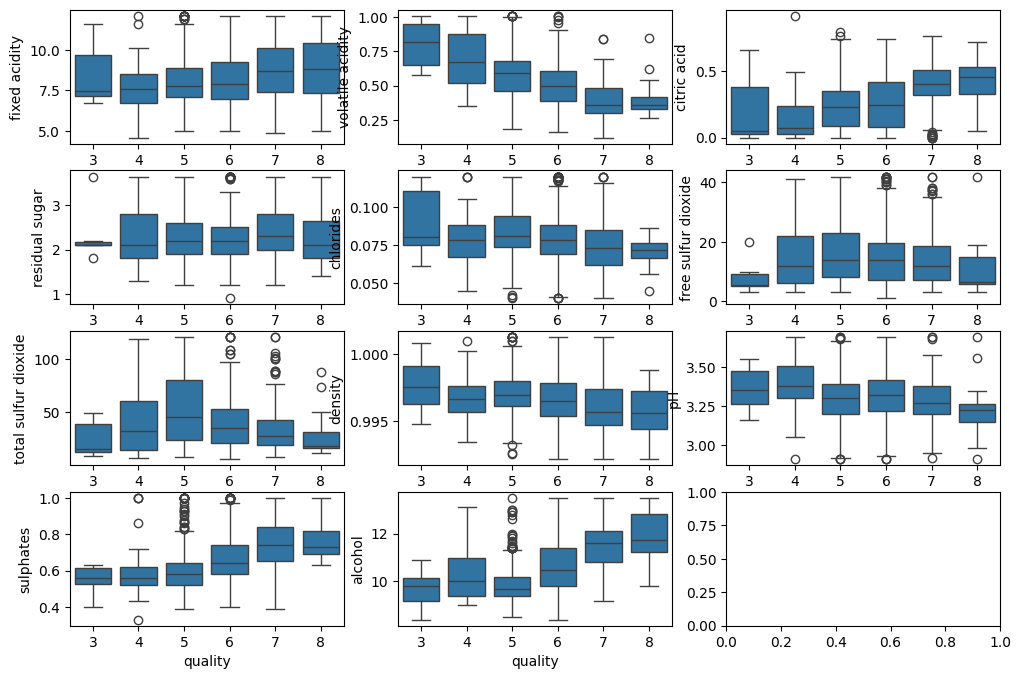

1143


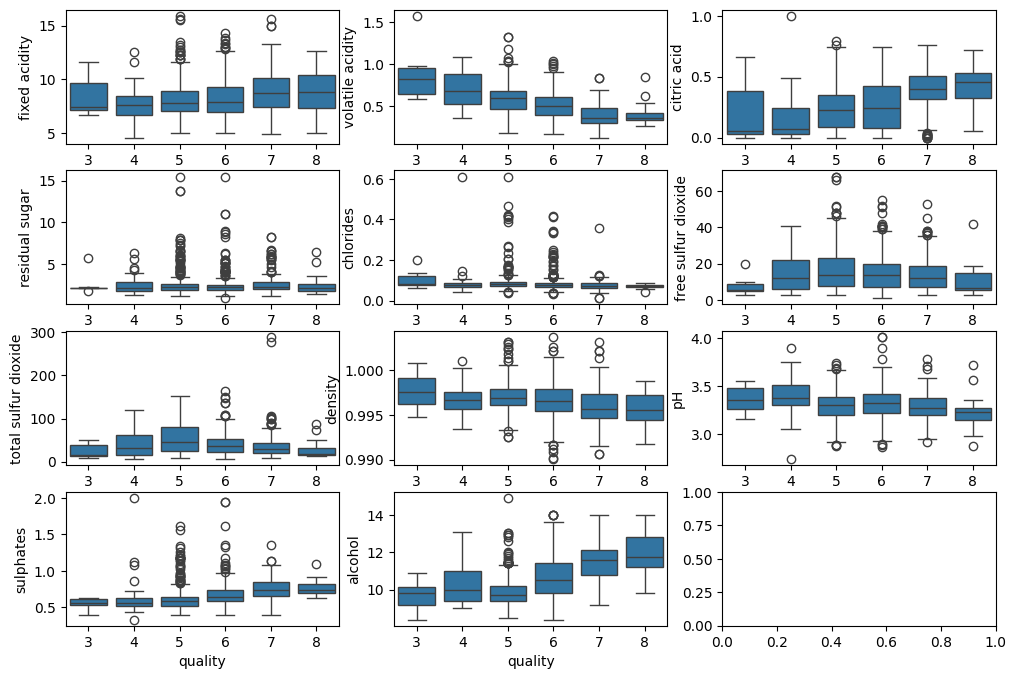

1143


In [12]:
fig, ax = plt.subplots(nrows=11//3+1,ncols= 3,figsize=(12, 8))

n = 0
t=0
for Y in cols:
    sns.boxplot(Data_Outlier_Capped, x="quality", y=Y, ax=ax[t,n])
    n += 1
    if n>=3:
        n=0
        t += 1
    # if t > 11:
    #     break
plt.show()
print(len(Data_Outlier_Capped))

fig, ax = plt.subplots(nrows=11//3+1,ncols= 3,figsize=(12, 8))

n = 0
t=0
for Y in cols:
    sns.boxplot(data, x="quality", y=Y, ax=ax[t,n])
    n += 1
    if n>=3:
        n=0
        t += 1
    # if t > 11:
    #     break
plt.show()
print(len(data))

In [13]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
X = Data_Outlier_Capped.drop(columns = "quality")
y = Data_Outlier_Capped["quality"]
X_Capped_train, X_Capped_test, y_Capped_train, y_Capped_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

X = data.drop(columns = "quality")
y = data["quality"]
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.2, random_state=42)


X_Capped_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
819,8.3,0.600,0.25,2.20,0.118,9.0,38.0,0.996160,3.15,0.53,9.8,1155
357,10.5,0.240,0.42,1.80,0.077,6.0,22.0,0.997600,3.21,1.00,10.8,504
385,9.5,0.460,0.49,3.65,0.064,5.0,17.0,0.998800,3.21,0.73,11.0,541
1057,5.6,0.620,0.03,1.50,0.080,6.0,13.0,0.994980,3.66,0.62,10.1,1480
161,8.9,0.590,0.50,2.00,0.120,27.0,81.0,0.996400,3.04,1.00,9.5,226
...,...,...,...,...,...,...,...,...,...,...,...,...
598,6.7,0.280,0.28,2.40,0.040,36.0,100.0,0.992157,3.26,0.39,11.7,837
352,10.7,0.350,0.53,2.60,0.070,5.0,16.0,0.997200,3.15,0.65,11.0,498
818,9.6,0.420,0.35,2.10,0.083,17.0,38.0,0.996220,3.23,0.66,11.1,1153
94,7.2,0.415,0.36,2.00,0.081,13.0,45.0,0.997200,3.48,0.64,9.2,137


In [14]:
# scaler = RobustScaler()
# scaler = MinMaxScaler()
scaler = StandardScaler()
for x in cols:
    X_Capped_train[[x]] = scaler.fit_transform(X_Capped_train[[x]])
    X_Capped_test[[x]] = scaler.transform(X_Capped_test[[x]])
    X_train[[x]] = scaler.fit_transform(X_train[[x]])
    X_test[[x]] = scaler.transform(X_test[[x]])
X_Capped_train.drop(columns=["Id","total sulfur dioxide","residual sugar"],inplace = True)
X_train.drop(columns=["Id","total sulfur dioxide","residual sugar"],inplace = True)

X_Capped_test.drop(columns=["Id","total sulfur dioxide","residual sugar"],inplace = True)
X_test.drop(columns=["Id","total sulfur dioxide","residual sugar"],inplace = True)

# 3. Eksperimen Model KNN


In [15]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
from sklearn.neighbors import KNeighborsClassifier
knn_1 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=1,weights = "distance")
knn_3 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=3,weights = "distance")
knn_5 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=5,weights = "distance")
knn_7 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=7,weights = "distance")
knn_9 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=9,weights = "distance")
knn_Manhatan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_Euclid = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn_1.fit(X_Capped_train,y_Capped_train)
y_Capped_pred_1 = knn_1.predict(X_Capped_test)
knn_1.fit(X_train,y_train)
y_pred_1 = knn_1.predict(X_test)


knn_3.fit(X_Capped_train,y_Capped_train)
y_Capped_pred_3 = knn_3.predict(X_Capped_test)
knn_3.fit(X_train,y_train)
y_pred_3 = knn_3.predict(X_test)


knn_5.fit(X_Capped_train,y_Capped_train)
y_Capped_pred_5 = knn_5.predict(X_Capped_test)
knn_5.fit(X_train,y_train)
y_pred_5 = knn_5.predict(X_test)


knn_7.fit(X_Capped_train,y_Capped_train)
y_Capped_pred_7 = knn_7.predict(X_Capped_test)
knn_7.fit(X_train,y_train)
y_pred_7 = knn_7.predict(X_test)


knn_9.fit(X_Capped_train,y_Capped_train)
y_Capped_pred_9 = knn_9.predict(X_Capped_test)
knn_9.fit(X_train,y_train)
y_pred_9 = knn_9.predict(X_test)

knn_Manhatan.fit(X_Capped_train,y_Capped_train)
y_Capped_pred_Manhatan = knn_Manhatan.predict(X_Capped_test)
knn_Manhatan.fit(X_train,y_train)
y_pred_Manhatan = knn_Manhatan.predict(X_test)

knn_Euclid.fit(X_Capped_train,y_Capped_train)
y_Capped_pred_Euclid = knn_Euclid.predict(X_Capped_test)
knn_Euclid.fit(X_train,y_train)
y_pred_Euclid = knn_Euclid.predict(X_test)

# 4. Evaluasi Model


Model Accuracy: 66.81%

Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  1  3  3  0  0]
 [ 0  0 73 22  2  0]
 [ 0  0 17 66  6  3]
 [ 0  0  2 14 13  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.14      0.25         7
           5       0.77      0.75      0.76        97
           6       0.61      0.72      0.66        92
           7       0.59      0.45      0.51        29
           8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.50      0.34      0.36       229
weighted avg       0.68      0.67      0.66       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

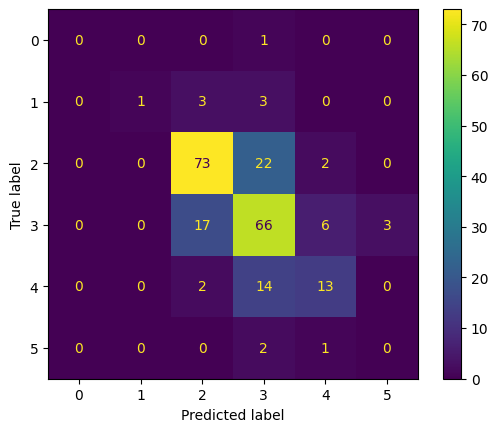

Model Accuracy: 66.81%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  3  3  0  0]
 [ 0  0 74 20  3  0]
 [ 0  0 21 64  5  2]
 [ 0  0  2 13 14  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.14      0.25         7
           5       0.73      0.76      0.75        97
           6       0.63      0.70      0.66        92
           7       0.61      0.48      0.54        29
           8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.49      0.35      0.37       229
weighted avg       0.67      0.67      0.66       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

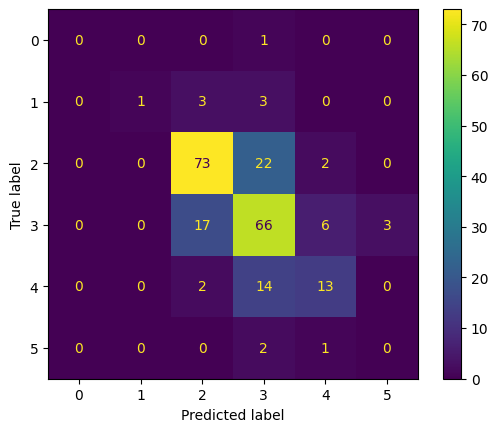

In [16]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
accuracy = accuracy_score(y_Capped_test, y_Capped_pred_1)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_Capped_test, y_Capped_pred_1))
print("\nClassification Report:")
print(classification_report(y_Capped_test, y_Capped_pred_1))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_1))
Confusion.plot()
plt.show()


accuracy = accuracy_score(y_test, y_pred_1)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_1))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_1))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_1))
Confusion.plot()
plt.show()

Model Accuracy: 71.62%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  4  2  0  0]
 [ 0  1 73 22  1  0]
 [ 0  0 12 73  6  1]
 [ 0  0  3  9 17  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.14      0.22         7
           5       0.78      0.75      0.77        97
           6       0.68      0.79      0.73        92
           7       0.68      0.59      0.63        29
           8       0.00      0.00      0.00         3

    accuracy                           0.72       229
   macro avg       0.44      0.38      0.39       229
weighted avg       0.71      0.72      0.71       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

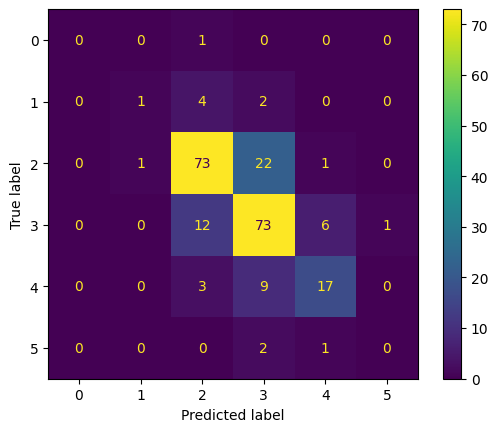

c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

Model Accuracy: 63.32%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  4  2  0  0]
 [ 0  0 70 26  1  0]
 [ 0  1 22 60  9  0]
 [ 0  0  1 14 14  0]
 [ 0  0  0  1  2  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.14      0.22         7
           5       0.71      0.72      0.72        97
           6       0.58      0.65      0.62        92
           7       0.54      0.48      0.51        29
           8       0.00      0.00      0.00         3

    accuracy                           0.63       229
   macro avg       0.39      0.33      0.34       229
weighted avg       0.62      0.63      0.62       229



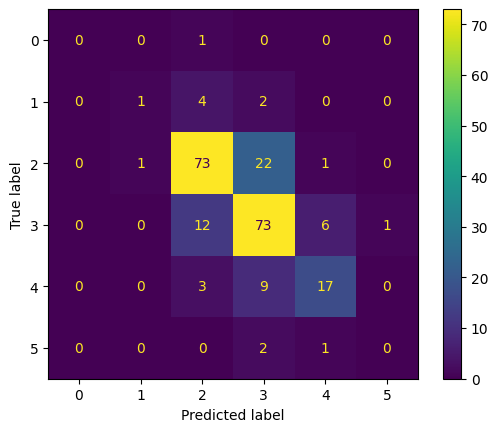

In [17]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
accuracy = accuracy_score(y_Capped_test, y_Capped_pred_3)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_Capped_test, y_Capped_pred_3))
print("\nClassification Report:")
print(classification_report(y_Capped_test, y_Capped_pred_3))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_3))
Confusion.plot()
plt.show()


accuracy = accuracy_score(y_test, y_pred_3)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_3))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_3))
Confusion.plot()
plt.show()

Model Accuracy: 67.69%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  5  1  0  0]
 [ 0  1 71 24  1  0]
 [ 0  0 15 68  9  0]
 [ 0  0  3 11 15  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.14      0.22         7
           5       0.75      0.73      0.74        97
           6       0.64      0.74      0.69        92
           7       0.58      0.52      0.55        29
           8       0.00      0.00      0.00         3

    accuracy                           0.68       229
   macro avg       0.41      0.36      0.37       229
weighted avg       0.66      0.68      0.67       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

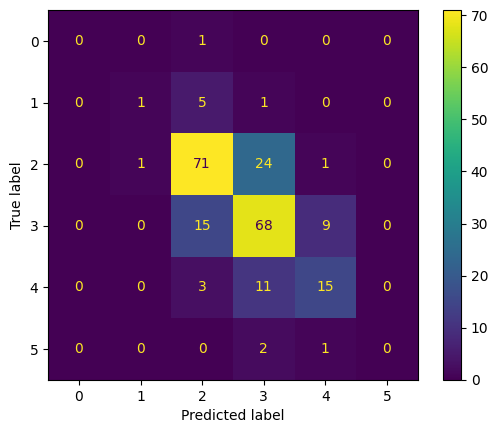

Model Accuracy: 64.63%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  1 71 24  1  0]
 [ 0  0 24 62  6  0]
 [ 0  0  2 12 15  0]
 [ 0  0  0  1  2  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.73      0.71        97
           6       0.61      0.67      0.64        92
           7       0.62      0.52      0.57        29
           8       0.00      0.00      0.00         3

    accuracy                           0.65       229
   macro avg       0.32      0.32      0.32       229
weighted avg       0.62      0.65      0.63       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

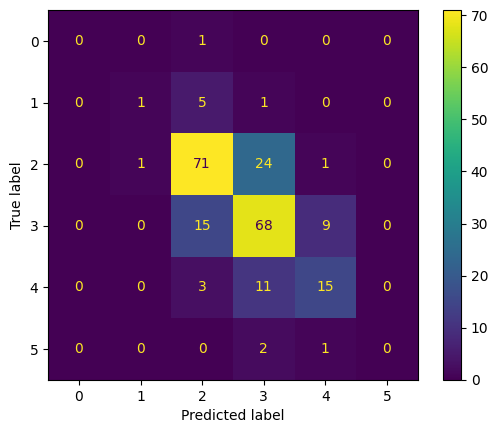

In [18]:
accuracy = accuracy_score(y_Capped_test, y_Capped_pred_5)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_Capped_test, y_Capped_pred_5))
print("\nClassification Report:")
print(classification_report(y_Capped_test, y_Capped_pred_5))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_5))
Confusion.plot()
plt.show()


accuracy = accuracy_score(y_test, y_pred_5)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_5))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_5))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_5))
Confusion.plot()
plt.show()

Model Accuracy: 66.81%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  5  1  0  0]
 [ 0  1 69 25  2  0]
 [ 0  0 15 69  8  0]
 [ 0  0  2 13 14  0]
 [ 0  0  0  2  1  0]]

Classification Report:


c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.14      0.22         7
           5       0.75      0.71      0.73        97
           6       0.63      0.75      0.68        92
           7       0.56      0.48      0.52        29
           8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.41      0.35      0.36       229
weighted avg       0.66      0.67      0.66       229



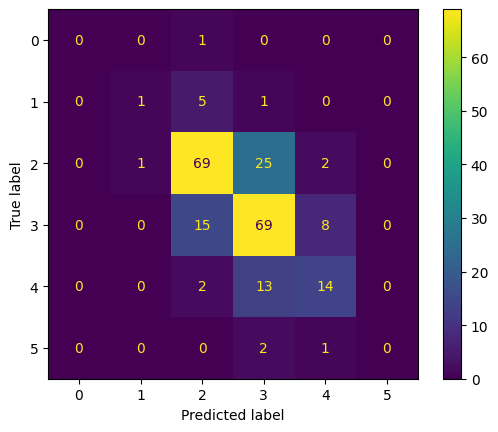

Model Accuracy: 65.94%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  1 73 22  1  0]
 [ 0  0 24 61  7  0]
 [ 0  0  2 10 17  0]
 [ 0  0  0  1  2  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.75      0.73        97
           6       0.63      0.66      0.65        92
           7       0.63      0.59      0.61        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.33      0.33      0.33       229
weighted avg       0.63      0.66      0.64       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

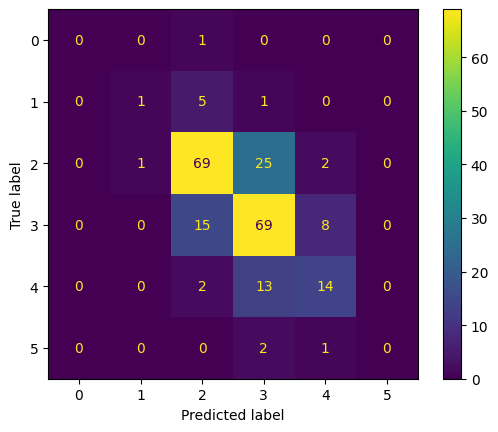

In [19]:
accuracy = accuracy_score(y_Capped_test, y_Capped_pred_7)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_Capped_test, y_Capped_pred_7))
print("\nClassification Report:")
print(classification_report(y_Capped_test, y_Capped_pred_7))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_7))
Confusion.plot()
plt.show()


accuracy = accuracy_score(y_test, y_pred_7)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_7))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_7))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_7))
Confusion.plot()
plt.show()

Model Accuracy: 65.94%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  5  1  0  0]
 [ 0  0 70 25  2  0]
 [ 0  0 18 65  9  0]
 [ 0  0  2 12 15  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.14      0.25         7
           5       0.73      0.72      0.73        97
           6       0.62      0.71      0.66        92
           7       0.56      0.52      0.54        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.48      0.35      0.36       229
weighted avg       0.66      0.66      0.65       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

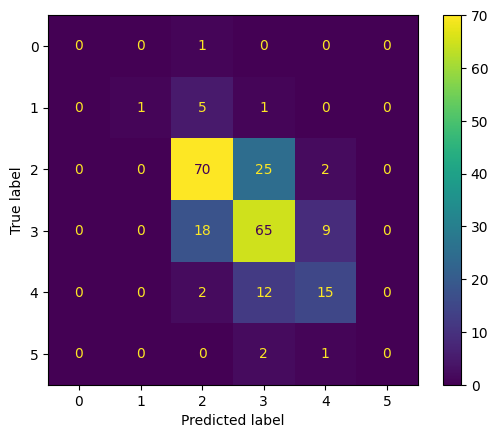

Model Accuracy: 65.07%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  1 72 23  1  0]
 [ 0  1 24 61  6  0]
 [ 0  0  3 10 16  0]
 [ 0  0  0  1  2  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.69      0.74      0.72        97
           6       0.62      0.66      0.64        92
           7       0.64      0.55      0.59        29
           8       0.00      0.00      0.00         3

    accuracy                           0.65       229
   macro avg       0.33      0.33      0.33       229
weighted avg       0.62      0.65      0.64       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

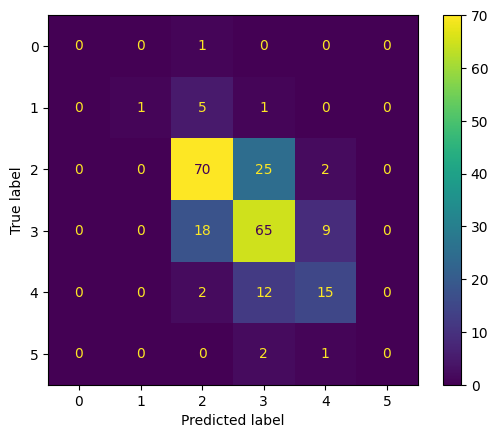

In [20]:
accuracy = accuracy_score(y_Capped_test, y_Capped_pred_9)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_Capped_test, y_Capped_pred_9))
print("\nClassification Report:")
print(classification_report(y_Capped_test, y_Capped_pred_9))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_9))
Confusion.plot()
plt.show()


accuracy = accuracy_score(y_test, y_pred_9)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_9))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_9))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_9))
Confusion.plot()
plt.show()

Model Accuracy: 62.45%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  3  3  0  0]
 [ 0  0 73 22  2  0]
 [ 0  0 24 60  7  1]
 [ 0  0  3 17  9  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.14      0.25         7
           5       0.70      0.75      0.73        97
           6       0.58      0.65      0.61        92
           7       0.47      0.31      0.38        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.46      0.31      0.33       229
weighted avg       0.62      0.62      0.61       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

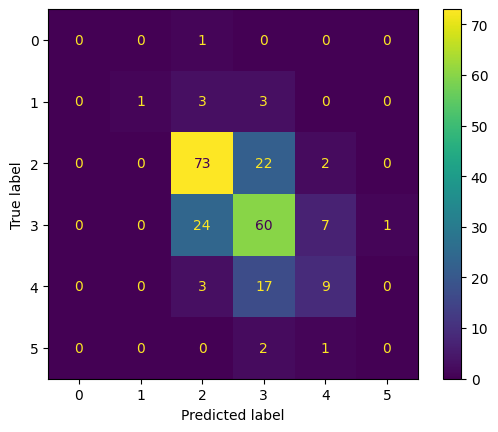

c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

Model Accuracy: 59.39%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  3  3  0  0]
 [ 0  0 70 24  3  0]
 [ 0  0 29 56  6  1]
 [ 0  0  2 18  9  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.14      0.25         7
           5       0.67      0.72      0.69        97
           6       0.54      0.61      0.57        92
           7       0.47      0.31      0.38        29
           8       0.00      0.00      0.00         3

    accuracy                           0.59       229
   macro avg       0.45      0.30      0.32       229
weighted avg       0.59      0.59      0.58       229



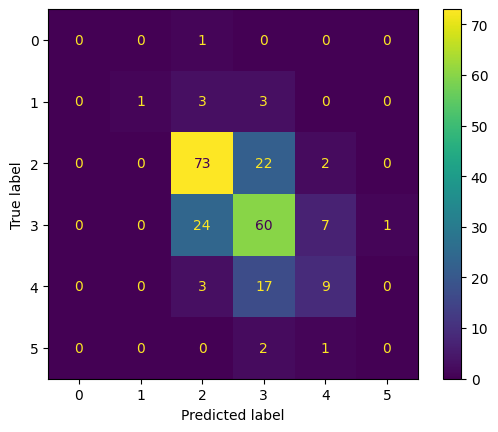

In [21]:
accuracy = accuracy_score(y_Capped_test, y_Capped_pred_Manhatan)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_Capped_test, y_Capped_pred_Manhatan))
print("\nClassification Report:")
print(classification_report(y_Capped_test, y_Capped_pred_Manhatan))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_Manhatan))
Confusion.plot()
plt.show()


accuracy = accuracy_score(y_test, y_pred_Manhatan)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_Manhatan))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_Manhatan))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_Manhatan))
Confusion.plot()
plt.show()

Model Accuracy: 65.94%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  4  2  0  0]
 [ 0  0 71 24  2  0]
 [ 0  0 20 66  6  0]
 [ 0  0  1 15 13  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.14      0.25         7
           5       0.73      0.73      0.73        97
           6       0.61      0.72      0.66        92
           7       0.59      0.45      0.51        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.49      0.34      0.36       229
weighted avg       0.66      0.66      0.65       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

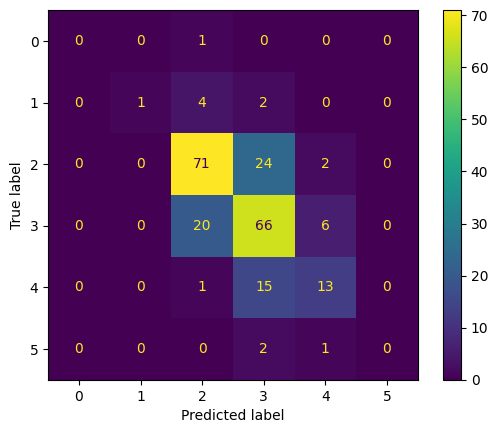

Model Accuracy: 59.39%

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  4  2  0  0]
 [ 0  0 72 23  2  0]
 [ 0  1 28 53  9  1]
 [ 0  0  0 19 10  0]
 [ 0  0  0  1  2  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.14      0.22         7
           5       0.69      0.74      0.71        97
           6       0.54      0.58      0.56        92
           7       0.43      0.34      0.38        29
           8       0.00      0.00      0.00         3

    accuracy                           0.59       229
   macro avg       0.36      0.30      0.31       229
weighted avg       0.58      0.59      0.58       229



c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

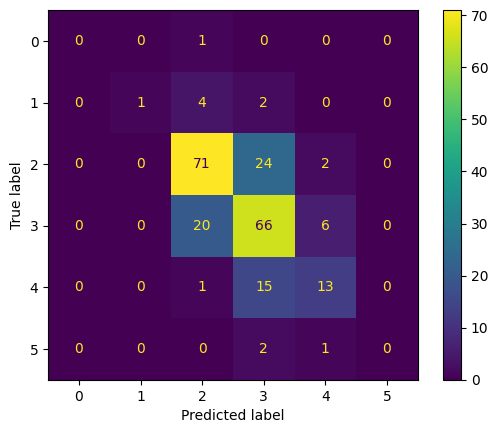

In [22]:

accuracy = accuracy_score(y_Capped_test, y_Capped_pred_Euclid)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_Capped_test, y_Capped_pred_Euclid))
print("\nClassification Report:")
print(classification_report(y_Capped_test, y_Capped_pred_Euclid))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_Euclid))
Confusion.plot()
plt.show()


accuracy = accuracy_score(y_test, y_pred_Euclid)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_Euclid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_Euclid))
Confusion = ConfusionMatrixDisplay(confusion_matrix(y_Capped_test, y_Capped_pred_Euclid))
Confusion.plot()
plt.show()

## Eksperimen Untuk Setiap kasus
Digunakan AI di code dibawah untuk menghemat waktu karena alur kerja sama dengan code code diatas, digunakan untuk mencoba banyak kasus dalam data handling dan model tune
Serta pembuatan grafik/tabel perbandingan peforma tiap kasus

In [23]:
# Menyiapkan variasi data: data polos (tanpa capping & tanpa scaling), capped tanpa scaling,
# serta capped dengan scaler lain (MinMaxScaler dan RobustScaler).
# Variabel baru dikasih nama beda biar gak nimpa variabel yang sudah ada di atas.
from sklearn.preprocessing import MinMaxScaler, RobustScaler

leaky_cols = ["Id", "total sulfur dioxide", "residual sugar"]

variasi_data = {}

# 1. Data Polos: mentah, tanpa capping outlier, tanpa scaling
X = data.drop(columns=["quality"] + leaky_cols)
y = data["quality"]
X_Polos_train, X_Polos_test, y_Polos_train, y_Polos_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
variasi_data["Polos (Raw)"] = (X_Polos_train, X_Polos_test, y_Polos_train, y_Polos_test)

# 2. Capped, tanpa scaling
X = Data_Outlier_Capped.drop(columns=["quality"] + leaky_cols)
y = Data_Outlier_Capped["quality"]
X_CappedOnly_train, X_CappedOnly_test, y_CappedOnly_train, y_CappedOnly_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
variasi_data["Capped (No Scaling)"] = (X_CappedOnly_train, X_CappedOnly_test, y_CappedOnly_train, y_CappedOnly_test)

# 3. Capped + StandardScaler -> pakai yang udah dihitung di atas, gak perlu diulang
variasi_data["Capped + StandardScaler"] = (X_Capped_train, X_Capped_test, y_Capped_train, y_Capped_test)

# 4. Capped + MinMaxScaler
X = Data_Outlier_Capped.drop(columns=["quality"] + leaky_cols)
y = Data_Outlier_Capped["quality"]
X_MinMax_train, X_MinMax_test, y_MinMax_train, y_MinMax_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
scaler = MinMaxScaler()
for x in cols:
    if x in X_MinMax_train.columns:
        X_MinMax_train[[x]] = scaler.fit_transform(X_MinMax_train[[x]])
        X_MinMax_test[[x]] = scaler.transform(X_MinMax_test[[x]])
variasi_data["Capped + MinMaxScaler"] = (X_MinMax_train, X_MinMax_test, y_MinMax_train, y_MinMax_test)

# 5. Capped + RobustScaler
X = Data_Outlier_Capped.drop(columns=["quality"] + leaky_cols)
y = Data_Outlier_Capped["quality"]
X_Robust_train, X_Robust_test, y_Robust_train, y_Robust_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
scaler = RobustScaler()
for x in cols:
    if x in X_Robust_train.columns:
        X_Robust_train[[x]] = scaler.fit_transform(X_Robust_train[[x]])
        X_Robust_test[[x]] = scaler.transform(X_Robust_test[[x]])
variasi_data["Capped + RobustScaler"] = (X_Robust_train, X_Robust_test, y_Robust_train, y_Robust_test)

# 6. Non-Capped + StandardScaler -> pakai yang udah dihitung di atas juga
variasi_data["Non-Capped + StandardScaler"] = (X_train, X_test, y_train, y_test)

print("Variasi data yang akan dibandingkan:")
for nama in variasi_data:
    print("-", nama)


Variasi data yang akan dibandingkan:
- Polos (Raw)
- Capped (No Scaling)
- Capped + StandardScaler
- Capped + MinMaxScaler
- Capped + RobustScaler
- Non-Capped + StandardScaler


In [24]:
# Loop semua kombinasi: variasi data x nilai k x distance metric
# Dicatat Train Accuracy & Test Accuracy tiap kombinasi biar kelihatan juga overfit/underfit-nya
hasil_eksperimen = []

for nama_variasi, (Xtr, Xte, ytr, yte) in variasi_data.items():
    for k in [3, 5, 7]:
        for metric in ["euclidean", "manhattan"]:
            knn_temp = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn_temp.fit(Xtr, ytr)

            train_acc = accuracy_score(ytr, knn_temp.predict(Xtr))
            test_acc = accuracy_score(yte, knn_temp.predict(Xte))

            hasil_eksperimen.append({
                "Variasi Data": nama_variasi,
                "k": k,
                "Metric": metric,
                "Train Accuracy": round(train_acc * 100, 2),
                "Test Accuracy": round(test_acc * 100, 2)
            })

df_hasil = pd.DataFrame(hasil_eksperimen)
df_hasil.sort_values("Test Accuracy", ascending=False)


,Variasi Data,k,Metric,Train Accuracy,Test Accuracy
22,Capped + MinMaxScaler,7,euclidean,64.33,66.81
14,Capped + StandardScaler,5,euclidean,66.63,65.94
23,Capped + MinMaxScaler,7,manhattan,64.88,65.94
16,Capped + StandardScaler,7,euclidean,64.77,65.07
17,Capped + StandardScaler,7,manhattan,63.79,65.07
29,Capped + RobustScaler,7,manhattan,64.33,64.19
20,Capped + MinMaxScaler,5,euclidean,66.85,63.76
12,Capped + StandardScaler,3,euclidean,74.84,62.88
35,Non-Capped + StandardScaler,7,manhattan,65.21,62.88
15,Capped + StandardScaler,5,manhattan,66.52,62.45


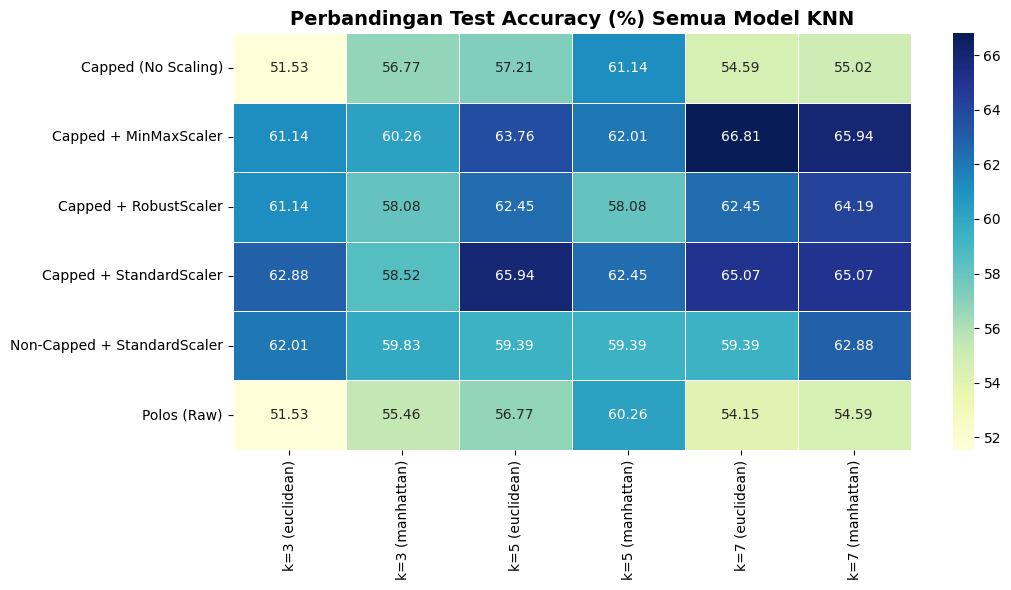

Model dengan Test Accuracy tertinggi:


Variasi Data      Capped + MinMaxScaler
k                                     7
Metric                        euclidean
Train Accuracy                    64.33
Test Accuracy                     66.81
Model                   k=7 (euclidean)
Name: 22, dtype: object

In [25]:
# Bandingkan semua model dalam satu heatmap (baris = variasi data, kolom = kombinasi k & metric)
df_hasil["Model"] = "k=" + df_hasil["k"].astype(str) + " (" + df_hasil["Metric"] + ")"
pivot_acc = df_hasil.pivot(index="Variasi Data", columns="Model", values="Test Accuracy")

plt.figure(figsize=(11, 6))
sns.heatmap(
    pivot_acc,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Perbandingan Test Accuracy (%) Semua Model KNN", fontsize=14, fontweight="bold")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

print("Model dengan Test Accuracy tertinggi:")
df_hasil.loc[df_hasil["Test Accuracy"].idxmax()]


### Gabungkan juga dengan model Minkowski (k=5, variasi p) + Manhattan/Euclid yang sudah kamu buat di atas


In [26]:
# Prediksinya udah ada dari cell eksperimen di atas (y_Capped_pred_1, y_pred_1, dst),
# jadi tinggal dihitung akurasinya aja, gak perlu fit ulang / gak nyentuh model kamu.
# Train Accuracy dikosongin (None) karena di kode aslimu cuma predict ke test set, gak ke train set.

model_kamu = {
    "Minkowski p=1 (k=5, distance)": (y_Capped_pred_1, y_pred_1),
    "Minkowski p=3 (k=5, distance)": (y_Capped_pred_3, y_pred_3),
    "Minkowski p=5 (k=5, distance)": (y_Capped_pred_5, y_pred_5),
    "Minkowski p=7 (k=5, distance)": (y_Capped_pred_7, y_pred_7),
    "Minkowski p=9 (k=5, distance)": (y_Capped_pred_9, y_pred_9),
    "Manhattan (k=5, uniform)": (y_Capped_pred_Manhatan, y_pred_Manhatan),
    "Euclidean (k=5, uniform)": (y_Capped_pred_Euclid, y_pred_Euclid),
}

for nama_model, (pred_capped, pred_noncapped) in model_kamu.items():
    hasil_eksperimen.append({
        "Variasi Data": "Capped + StandardScaler",
        "k": 5,
        "Metric": nama_model,
        "Train Accuracy": None,
        "Test Accuracy": round(accuracy_score(y_Capped_test, pred_capped) * 100, 2)
    })
    hasil_eksperimen.append({
        "Variasi Data": "Non-Capped + StandardScaler",
        "k": 5,
        "Metric": nama_model,
        "Train Accuracy": None,
        "Test Accuracy": round(accuracy_score(y_test, pred_noncapped) * 100, 2)
    })

df_hasil = pd.DataFrame(hasil_eksperimen)
df_hasil.sort_values("Test Accuracy", ascending=False)


,Variasi Data,k,Metric,Train Accuracy,Test Accuracy
38,Capped + StandardScaler,5,"Minkowski p=3 (k=5, distance)",NaN,71.62
40,Capped + StandardScaler,5,"Minkowski p=5 (k=5, distance)",NaN,67.69
37,Non-Capped + StandardScaler,5,"Minkowski p=1 (k=5, distance)",NaN,66.81
22,Capped + MinMaxScaler,7,euclidean,64.33,66.81
42,Capped + StandardScaler,5,"Minkowski p=7 (k=5, distance)",NaN,66.81
36,Capped + StandardScaler,5,"Minkowski p=1 (k=5, distance)",NaN,66.81
23,Capped + MinMaxScaler,7,manhattan,64.88,65.94
48,Capped + StandardScaler,5,"Euclidean (k=5, uniform)",NaN,65.94
43,Non-Capped + StandardScaler,5,"Minkowski p=7 (k=5, distance)",NaN,65.94
44,Capped + StandardScaler,5,"Minkowski p=9 (k=5, distance)",NaN,65.94


### Eksperimen sendiri (gaya sama kayak cell k=5 di atas) untuk data Polos, Capped Polos, MinMax, dan Robust


In [27]:
# Eksperimen KNN (k=5, variasi p Minkowski + Manhattan + Euclidean) untuk data Polos (mentah, tanpa capping, tanpa scaling)
knn_Polos_1 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=1, weights="distance")
knn_Polos_3 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=3, weights="distance")
knn_Polos_5 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=5, weights="distance")
knn_Polos_7 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=7, weights="distance")
knn_Polos_9 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=9, weights="distance")
knn_Polos_Manhatan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_Polos_Euclid = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn_Polos_1.fit(X_Polos_train,y_Polos_train)
y_Polos_pred_1 = knn_Polos_1.predict(X_Polos_test)

knn_Polos_3.fit(X_Polos_train,y_Polos_train)
y_Polos_pred_3 = knn_Polos_3.predict(X_Polos_test)

knn_Polos_5.fit(X_Polos_train,y_Polos_train)
y_Polos_pred_5 = knn_Polos_5.predict(X_Polos_test)

knn_Polos_7.fit(X_Polos_train,y_Polos_train)
y_Polos_pred_7 = knn_Polos_7.predict(X_Polos_test)

knn_Polos_9.fit(X_Polos_train,y_Polos_train)
y_Polos_pred_9 = knn_Polos_9.predict(X_Polos_test)

knn_Polos_Manhatan.fit(X_Polos_train,y_Polos_train)
y_Polos_pred_Manhatan = knn_Polos_Manhatan.predict(X_Polos_test)

knn_Polos_Euclid.fit(X_Polos_train,y_Polos_train)
y_Polos_pred_Euclid = knn_Polos_Euclid.predict(X_Polos_test)


In [28]:
# Eksperimen KNN (k=5, variasi p Minkowski + Manhattan + Euclidean) untuk data Capped Polos (capped, tanpa scaling)
knn_CappedPolos_1 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=1, weights="distance")
knn_CappedPolos_3 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=3, weights="distance")
knn_CappedPolos_5 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=5, weights="distance")
knn_CappedPolos_7 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=7, weights="distance")
knn_CappedPolos_9 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=9, weights="distance")
knn_CappedPolos_Manhatan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_CappedPolos_Euclid = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn_CappedPolos_1.fit(X_CappedOnly_train,y_CappedOnly_train)
y_CappedPolos_pred_1 = knn_CappedPolos_1.predict(X_CappedOnly_test)

knn_CappedPolos_3.fit(X_CappedOnly_train,y_CappedOnly_train)
y_CappedPolos_pred_3 = knn_CappedPolos_3.predict(X_CappedOnly_test)

knn_CappedPolos_5.fit(X_CappedOnly_train,y_CappedOnly_train)
y_CappedPolos_pred_5 = knn_CappedPolos_5.predict(X_CappedOnly_test)

knn_CappedPolos_7.fit(X_CappedOnly_train,y_CappedOnly_train)
y_CappedPolos_pred_7 = knn_CappedPolos_7.predict(X_CappedOnly_test)

knn_CappedPolos_9.fit(X_CappedOnly_train,y_CappedOnly_train)
y_CappedPolos_pred_9 = knn_CappedPolos_9.predict(X_CappedOnly_test)

knn_CappedPolos_Manhatan.fit(X_CappedOnly_train,y_CappedOnly_train)
y_CappedPolos_pred_Manhatan = knn_CappedPolos_Manhatan.predict(X_CappedOnly_test)

knn_CappedPolos_Euclid.fit(X_CappedOnly_train,y_CappedOnly_train)
y_CappedPolos_pred_Euclid = knn_CappedPolos_Euclid.predict(X_CappedOnly_test)


In [29]:
# Eksperimen KNN (k=5, variasi p Minkowski + Manhattan + Euclidean) untuk data Capped + MinMaxScaler
knn_MinMax_1 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=1, weights="distance")
knn_MinMax_3 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=3, weights="distance")
knn_MinMax_5 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=5, weights="distance")
knn_MinMax_7 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=7, weights="distance")
knn_MinMax_9 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=9, weights="distance")
knn_MinMax_Manhatan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_MinMax_Euclid = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn_MinMax_1.fit(X_MinMax_train,y_MinMax_train)
y_MinMax_pred_1 = knn_MinMax_1.predict(X_MinMax_test)

knn_MinMax_3.fit(X_MinMax_train,y_MinMax_train)
y_MinMax_pred_3 = knn_MinMax_3.predict(X_MinMax_test)

knn_MinMax_5.fit(X_MinMax_train,y_MinMax_train)
y_MinMax_pred_5 = knn_MinMax_5.predict(X_MinMax_test)

knn_MinMax_7.fit(X_MinMax_train,y_MinMax_train)
y_MinMax_pred_7 = knn_MinMax_7.predict(X_MinMax_test)

knn_MinMax_9.fit(X_MinMax_train,y_MinMax_train)
y_MinMax_pred_9 = knn_MinMax_9.predict(X_MinMax_test)

knn_MinMax_Manhatan.fit(X_MinMax_train,y_MinMax_train)
y_MinMax_pred_Manhatan = knn_MinMax_Manhatan.predict(X_MinMax_test)

knn_MinMax_Euclid.fit(X_MinMax_train,y_MinMax_train)
y_MinMax_pred_Euclid = knn_MinMax_Euclid.predict(X_MinMax_test)


In [30]:
# Eksperimen KNN (k=5, variasi p Minkowski + Manhattan + Euclidean) untuk data Capped + RobustScaler
knn_Robust_1 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=1, weights="distance")
knn_Robust_3 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=3, weights="distance")
knn_Robust_5 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=5, weights="distance")
knn_Robust_7 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=7, weights="distance")
knn_Robust_9 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=9, weights="distance")
knn_Robust_Manhatan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_Robust_Euclid = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn_Robust_1.fit(X_Robust_train,y_Robust_train)
y_Robust_pred_1 = knn_Robust_1.predict(X_Robust_test)

knn_Robust_3.fit(X_Robust_train,y_Robust_train)
y_Robust_pred_3 = knn_Robust_3.predict(X_Robust_test)

knn_Robust_5.fit(X_Robust_train,y_Robust_train)
y_Robust_pred_5 = knn_Robust_5.predict(X_Robust_test)

knn_Robust_7.fit(X_Robust_train,y_Robust_train)
y_Robust_pred_7 = knn_Robust_7.predict(X_Robust_test)

knn_Robust_9.fit(X_Robust_train,y_Robust_train)
y_Robust_pred_9 = knn_Robust_9.predict(X_Robust_test)

knn_Robust_Manhatan.fit(X_Robust_train,y_Robust_train)
y_Robust_pred_Manhatan = knn_Robust_Manhatan.predict(X_Robust_test)

knn_Robust_Euclid.fit(X_Robust_train,y_Robust_train)
y_Robust_pred_Euclid = knn_Robust_Euclid.predict(X_Robust_test)


In [31]:
# Masukkan hasil eksperimen Polos, Capped Polos, MinMax, Robust ke tabel perbandingan yang sama
variasi_baru = {
    "Polos (Raw)": (y_Polos_test, {
        "Minkowski p=1 (k=5, distance)": y_Polos_pred_1,
        "Minkowski p=3 (k=5, distance)": y_Polos_pred_3,
        "Minkowski p=5 (k=5, distance)": y_Polos_pred_5,
        "Minkowski p=7 (k=5, distance)": y_Polos_pred_7,
        "Minkowski p=9 (k=5, distance)": y_Polos_pred_9,
        "Manhattan (k=5, uniform)": y_Polos_pred_Manhatan,
        "Euclidean (k=5, uniform)": y_Polos_pred_Euclid,
    }),
    "Capped (No Scaling)": (y_CappedOnly_test, {
        "Minkowski p=1 (k=5, distance)": y_CappedPolos_pred_1,
        "Minkowski p=3 (k=5, distance)": y_CappedPolos_pred_3,
        "Minkowski p=5 (k=5, distance)": y_CappedPolos_pred_5,
        "Minkowski p=7 (k=5, distance)": y_CappedPolos_pred_7,
        "Minkowski p=9 (k=5, distance)": y_CappedPolos_pred_9,
        "Manhattan (k=5, uniform)": y_CappedPolos_pred_Manhatan,
        "Euclidean (k=5, uniform)": y_CappedPolos_pred_Euclid,
    }),
    "Capped + MinMaxScaler": (y_MinMax_test, {
        "Minkowski p=1 (k=5, distance)": y_MinMax_pred_1,
        "Minkowski p=3 (k=5, distance)": y_MinMax_pred_3,
        "Minkowski p=5 (k=5, distance)": y_MinMax_pred_5,
        "Minkowski p=7 (k=5, distance)": y_MinMax_pred_7,
        "Minkowski p=9 (k=5, distance)": y_MinMax_pred_9,
        "Manhattan (k=5, uniform)": y_MinMax_pred_Manhatan,
        "Euclidean (k=5, uniform)": y_MinMax_pred_Euclid,
    }),
    "Capped + RobustScaler": (y_Robust_test, {
        "Minkowski p=1 (k=5, distance)": y_Robust_pred_1,
        "Minkowski p=3 (k=5, distance)": y_Robust_pred_3,
        "Minkowski p=5 (k=5, distance)": y_Robust_pred_5,
        "Minkowski p=7 (k=5, distance)": y_Robust_pred_7,
        "Minkowski p=9 (k=5, distance)": y_Robust_pred_9,
        "Manhattan (k=5, uniform)": y_Robust_pred_Manhatan,
        "Euclidean (k=5, uniform)": y_Robust_pred_Euclid,
    }),
}

for nama_variasi, (y_true, prediksi_dict) in variasi_baru.items():
    for nama_model, y_pred_temp in prediksi_dict.items():
        hasil_eksperimen.append({
            "Variasi Data": nama_variasi,
            "k": 5,
            "Metric": nama_model,
            "Train Accuracy": None,
            "Test Accuracy": round(accuracy_score(y_true, y_pred_temp) * 100, 2)
        })

df_hasil = pd.DataFrame(hasil_eksperimen)
df_hasil.sort_values("Test Accuracy", ascending=False)


,Variasi Data,k,Metric,Train Accuracy,Test Accuracy
38,Capped + StandardScaler,5,"Minkowski p=3 (k=5, distance)",NaN,71.62
65,Capped + MinMaxScaler,5,"Minkowski p=3 (k=5, distance)",NaN,69.00
72,Capped + RobustScaler,5,"Minkowski p=3 (k=5, distance)",NaN,68.56
66,Capped + MinMaxScaler,5,"Minkowski p=5 (k=5, distance)",NaN,68.12
40,Capped + StandardScaler,5,"Minkowski p=5 (k=5, distance)",NaN,67.69
...,...,...,...,...,...
5,Polos (Raw),7,manhattan,64.99,54.59
10,Capped (No Scaling),7,euclidean,64.77,54.59
4,Polos (Raw),7,euclidean,65.21,54.15
6,Capped (No Scaling),3,euclidean,75.16,51.53


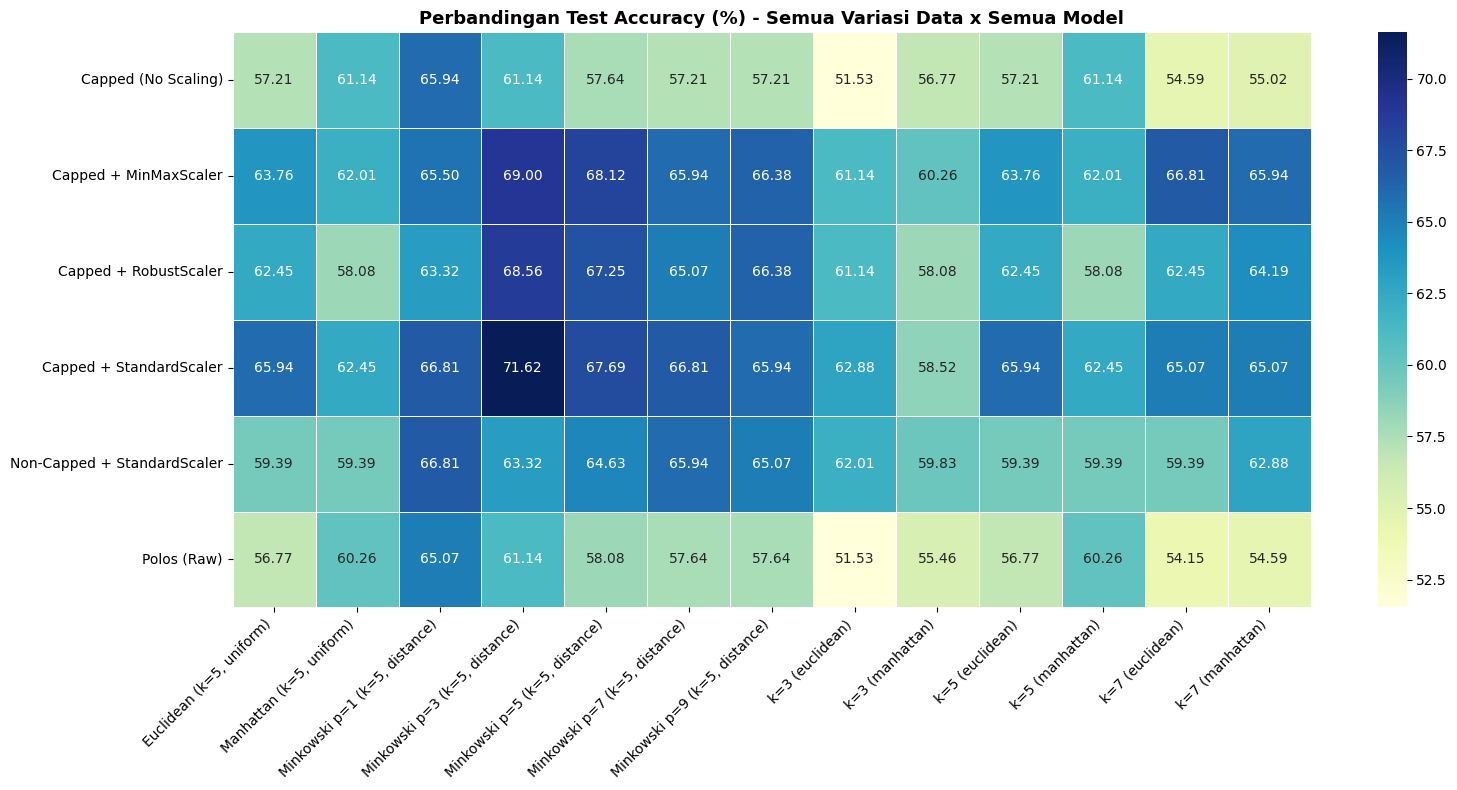

Model & variasi data dengan Test Accuracy tertinggi:


Variasi Data            Capped + StandardScaler
k                                             5
Metric            Minkowski p=3 (k=5, distance)
Train Accuracy                              NaN
Test Accuracy                             71.62
Model             Minkowski p=3 (k=5, distance)
Name: 38, dtype: object

In [32]:
# Heatmap final: semua variasi data x semua model (grid k/metric + Minkowski p + Manhattan/Euclid)
df_hasil["Model"] = df_hasil.apply(
    lambda row: row["Metric"] if "Minkowski" in row["Metric"] or "uniform" in row["Metric"]
                else f'k={row["k"]} ({row["Metric"]})',
    axis=1
)
pivot_acc_final = df_hasil.pivot_table(index="Variasi Data", columns="Model", values="Test Accuracy")

plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_acc_final,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Perbandingan Test Accuracy (%) - Semua Variasi Data x Semua Model", fontsize=13, fontweight="bold")
plt.ylabel("")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('heatmap.png', dpi=300)
plt.show()

print("Model & variasi data dengan Test Accuracy tertinggi:")
df_hasil.loc[df_hasil["Test Accuracy"].idxmax()]


### Lengkapi Train Accuracy yang masih kosong (model p=1..9, Manhattan, Euclidean di semua variasi data)


In [33]:
# Untuk sisi Non-Capped, knn_1 dkk masih menyimpan fit terakhir (ke X_train/y_train) jadi tinggal dipakai lagi.
# Untuk sisi Capped + StandardScaler, objek aslinya udah ketimpa fit kedua (ke X_train), jadi di-fit ulang
# di variabel baru khusus buat ngecek Train Accuracy-nya, gak nyentuh knn_1 dkk aslimu.

hyperparams_model_kamu = {
    "Minkowski p=1 (k=5, distance)": dict(n_neighbors=5, metric='minkowski', p=1, weights="distance"),
    "Minkowski p=3 (k=5, distance)": dict(n_neighbors=5, metric='minkowski', p=3, weights="distance"),
    "Minkowski p=5 (k=5, distance)": dict(n_neighbors=5, metric='minkowski', p=5, weights="distance"),
    "Minkowski p=7 (k=5, distance)": dict(n_neighbors=5, metric='minkowski', p=7, weights="distance"),
    "Minkowski p=9 (k=5, distance)": dict(n_neighbors=5, metric='minkowski', p=9, weights="distance"),
    "Manhattan (k=5, uniform)": dict(n_neighbors=5, metric='manhattan'),
    "Euclidean (k=5, uniform)": dict(n_neighbors=5, metric='euclidean'),
}

model_kamu_train_acc = {}

for nama_model, params in hyperparams_model_kamu.items():
    knn_capped_check = KNeighborsClassifier(**params)
    knn_capped_check.fit(X_Capped_train, y_Capped_train)
    model_kamu_train_acc[(nama_model, "Capped + StandardScaler")] = accuracy_score(
        y_Capped_train, knn_capped_check.predict(X_Capped_train)
    )

model_kamu_train_acc[("Minkowski p=1 (k=5, distance)", "Non-Capped + StandardScaler")] = accuracy_score(y_train, knn_1.predict(X_train))
model_kamu_train_acc[("Minkowski p=3 (k=5, distance)", "Non-Capped + StandardScaler")] = accuracy_score(y_train, knn_3.predict(X_train))
model_kamu_train_acc[("Minkowski p=5 (k=5, distance)", "Non-Capped + StandardScaler")] = accuracy_score(y_train, knn_5.predict(X_train))
model_kamu_train_acc[("Minkowski p=7 (k=5, distance)", "Non-Capped + StandardScaler")] = accuracy_score(y_train, knn_7.predict(X_train))
model_kamu_train_acc[("Minkowski p=9 (k=5, distance)", "Non-Capped + StandardScaler")] = accuracy_score(y_train, knn_9.predict(X_train))
model_kamu_train_acc[("Manhattan (k=5, uniform)", "Non-Capped + StandardScaler")] = accuracy_score(y_train, knn_Manhatan.predict(X_train))
model_kamu_train_acc[("Euclidean (k=5, uniform)", "Non-Capped + StandardScaler")] = accuracy_score(y_train, knn_Euclid.predict(X_train))

# Untuk data Polos, Capped Polos, MinMax, Robust - objeknya cuma di-fit sekali di cell atas,
# jadi bisa langsung dipakai predict ke train set masing-masing.
variasi_baru_info = {
    "Polos (Raw)": ("Polos", X_Polos_train, y_Polos_train),
    "Capped (No Scaling)": ("CappedPolos", X_CappedOnly_train, y_CappedOnly_train),
    "Capped + MinMaxScaler": ("MinMax", X_MinMax_train, y_MinMax_train),
    "Capped + RobustScaler": ("Robust", X_Robust_train, y_Robust_train),
}

suffix_ke_nama_model = {
    "1": "Minkowski p=1 (k=5, distance)",
    "3": "Minkowski p=3 (k=5, distance)",
    "5": "Minkowski p=5 (k=5, distance)",
    "7": "Minkowski p=7 (k=5, distance)",
    "9": "Minkowski p=9 (k=5, distance)",
    "Manhatan": "Manhattan (k=5, uniform)",
    "Euclid": "Euclidean (k=5, uniform)",
}

for nama_variasi, (prefix, X_train_temp, y_train_temp) in variasi_baru_info.items():
    for suffix, nama_model in suffix_ke_nama_model.items():
        model_temp = globals()[f"knn_{prefix}_{suffix}"]
        model_kamu_train_acc[(nama_model, nama_variasi)] = accuracy_score(
            y_train_temp, model_temp.predict(X_train_temp)
        )

print(f"Total Train Accuracy yang berhasil dihitung: {len(model_kamu_train_acc)}")


Total Train Accuracy yang berhasil dihitung: 42


In [34]:
# Isi kolom Train Accuracy yang masih kosong pakai hasil di atas
def isi_train_acc(row):
    key = (row["Metric"], row["Variasi Data"])
    if pd.isna(row["Train Accuracy"]) and key in model_kamu_train_acc:
        return round(model_kamu_train_acc[key] * 100, 2)
    return row["Train Accuracy"]

df_hasil["Train Accuracy"] = df_hasil.apply(isi_train_acc, axis=1)
hasil_eksperimen = df_hasil.to_dict("records")

df_hasil.sort_values("Test Accuracy", ascending=False)


,Variasi Data,k,Metric,Train Accuracy,Test Accuracy,Model
38,Capped + StandardScaler,5,"Minkowski p=3 (k=5, distance)",100.00,71.62,"Minkowski p=3 (k=5, distance)"
65,Capped + MinMaxScaler,5,"Minkowski p=3 (k=5, distance)",100.00,69.00,"Minkowski p=3 (k=5, distance)"
72,Capped + RobustScaler,5,"Minkowski p=3 (k=5, distance)",100.00,68.56,"Minkowski p=3 (k=5, distance)"
66,Capped + MinMaxScaler,5,"Minkowski p=5 (k=5, distance)",100.00,68.12,"Minkowski p=5 (k=5, distance)"
40,Capped + StandardScaler,5,"Minkowski p=5 (k=5, distance)",100.00,67.69,"Minkowski p=5 (k=5, distance)"
...,...,...,...,...,...,...
5,Polos (Raw),7,manhattan,64.99,54.59,k=7 (manhattan)
10,Capped (No Scaling),7,euclidean,64.77,54.59,k=7 (euclidean)
4,Polos (Raw),7,euclidean,65.21,54.15,k=7 (euclidean)
6,Capped (No Scaling),3,euclidean,75.16,51.53,k=3 (euclidean)


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

Pada tahap Persiapan Dataset data di load di kaggle dan mendapatkan semua informasi terkait dataset, lalu dari informasi itu ditemukan bahwa data tidak punya missing value, hampir semua data berbentuk float(angka desimal) kecuali quality dan id hal ini berarti tidak perlu dilakukan encoder karena tidak ada data categorical atau yang berbentuk text pada data.

Tahap selanjutnya yaitu preprocessing saya mencari oulier dengan menggunakan boxplot ditemukan banyak sekali outlier pada fitur terutama residual sugar, chlorides, sulphates dll. maka saya mengatasi hal tersebut dengan cara membatasi nilai dengan nilai hanya di rentan Q1 - 1.5×IQR sampai Q3 + 1.5×IQR (Metode IQR) yang saya temukan dari internet (geekforgeeks), menurut saya lebih cocok daripada mendrop oulier karena outliernya banyak(bisa memotong banyak informasi), dan jika di ganti dengan angka lain pun bisa merusak informasi.Selanjutnya saya melakukan scaling terhadap fitur karena dilihat dari standar deviasi tiap fitur terdapat fitur dengan standar deviasi lebih dari 1 dan ada yang di rentan 0-1 karena itu untuk mencegah bias terhadap nilai fitur yang memang mempunyai rentan nilai lebih besar maka dilakukan scaling agar model tidak bias terhadap nilai besar, dipilih standar scaler karena berfokus untuk menjadikan standar deviasi menjadi 1.  Kemudian dilakukan pemetaaan heatmap untuk melihat hubungan antar fitur ditemukan bahwa fitur id karena hanya identifier(hanya untuk mengindentifikasi secara unit objek) dan residual sugar memiliki keterhubungan dengan quality secara minim serta ketika saya perhatikan ada 2 fitur yang mirip yaitu total sulfur dioxide dan free sulfur dioxide, ketika saya mencari keterhubungan 2 fitur tersebut dengan wine saya mendapat artikel mengenai free sulfur dioxide jauh lebih mudah daripada total sulfur dioxide oleh karena itu saya mendrop free sulfur dioxide dari fitur dan terbukti pada saat itu saya membandingkan jika free sulfur dioxide di drop maka akurasinya lebih bagus sehingga tiga fitur yaitu id,residual sugar dan free sulfur dioxide saya drop.

Selanjutnya pada tahap eksperimen dan evaluasi model, saya split datanya 80% untuk train dan 20% untuk test (sesuai contoh) dan mengetes berbagai model knn baik ditune dari k, metrik dan weight(saya sebenarnya sudah mengetes sendiri menggunakan kode sendiri untuk metrik manhatan dan euclidean dan weight default(uniform) serta weight distance namun saya mengetes sendiri dengan mengubah kode saya bukan menambahkan oleh karena itu semua perbandingan sisanya diluar weight distance  dan metrik minkowski ditulis AI di akhir) pada intinya saya menemukan bahwa metrik minkowski, k = 3 dan  weight distance kombinasi terbaik metrik minkowski, k = 3 dan weight distance menambah akurasi sekitar 5 persen daripada kombinasi lain. yang terakhir bagian eksperimen untuk setiap kasus serta tabel dan heatmap perbandingan peforma model ditulis AI untuk menghemat waktu karena stepnya sama saja dengan analisis saya.


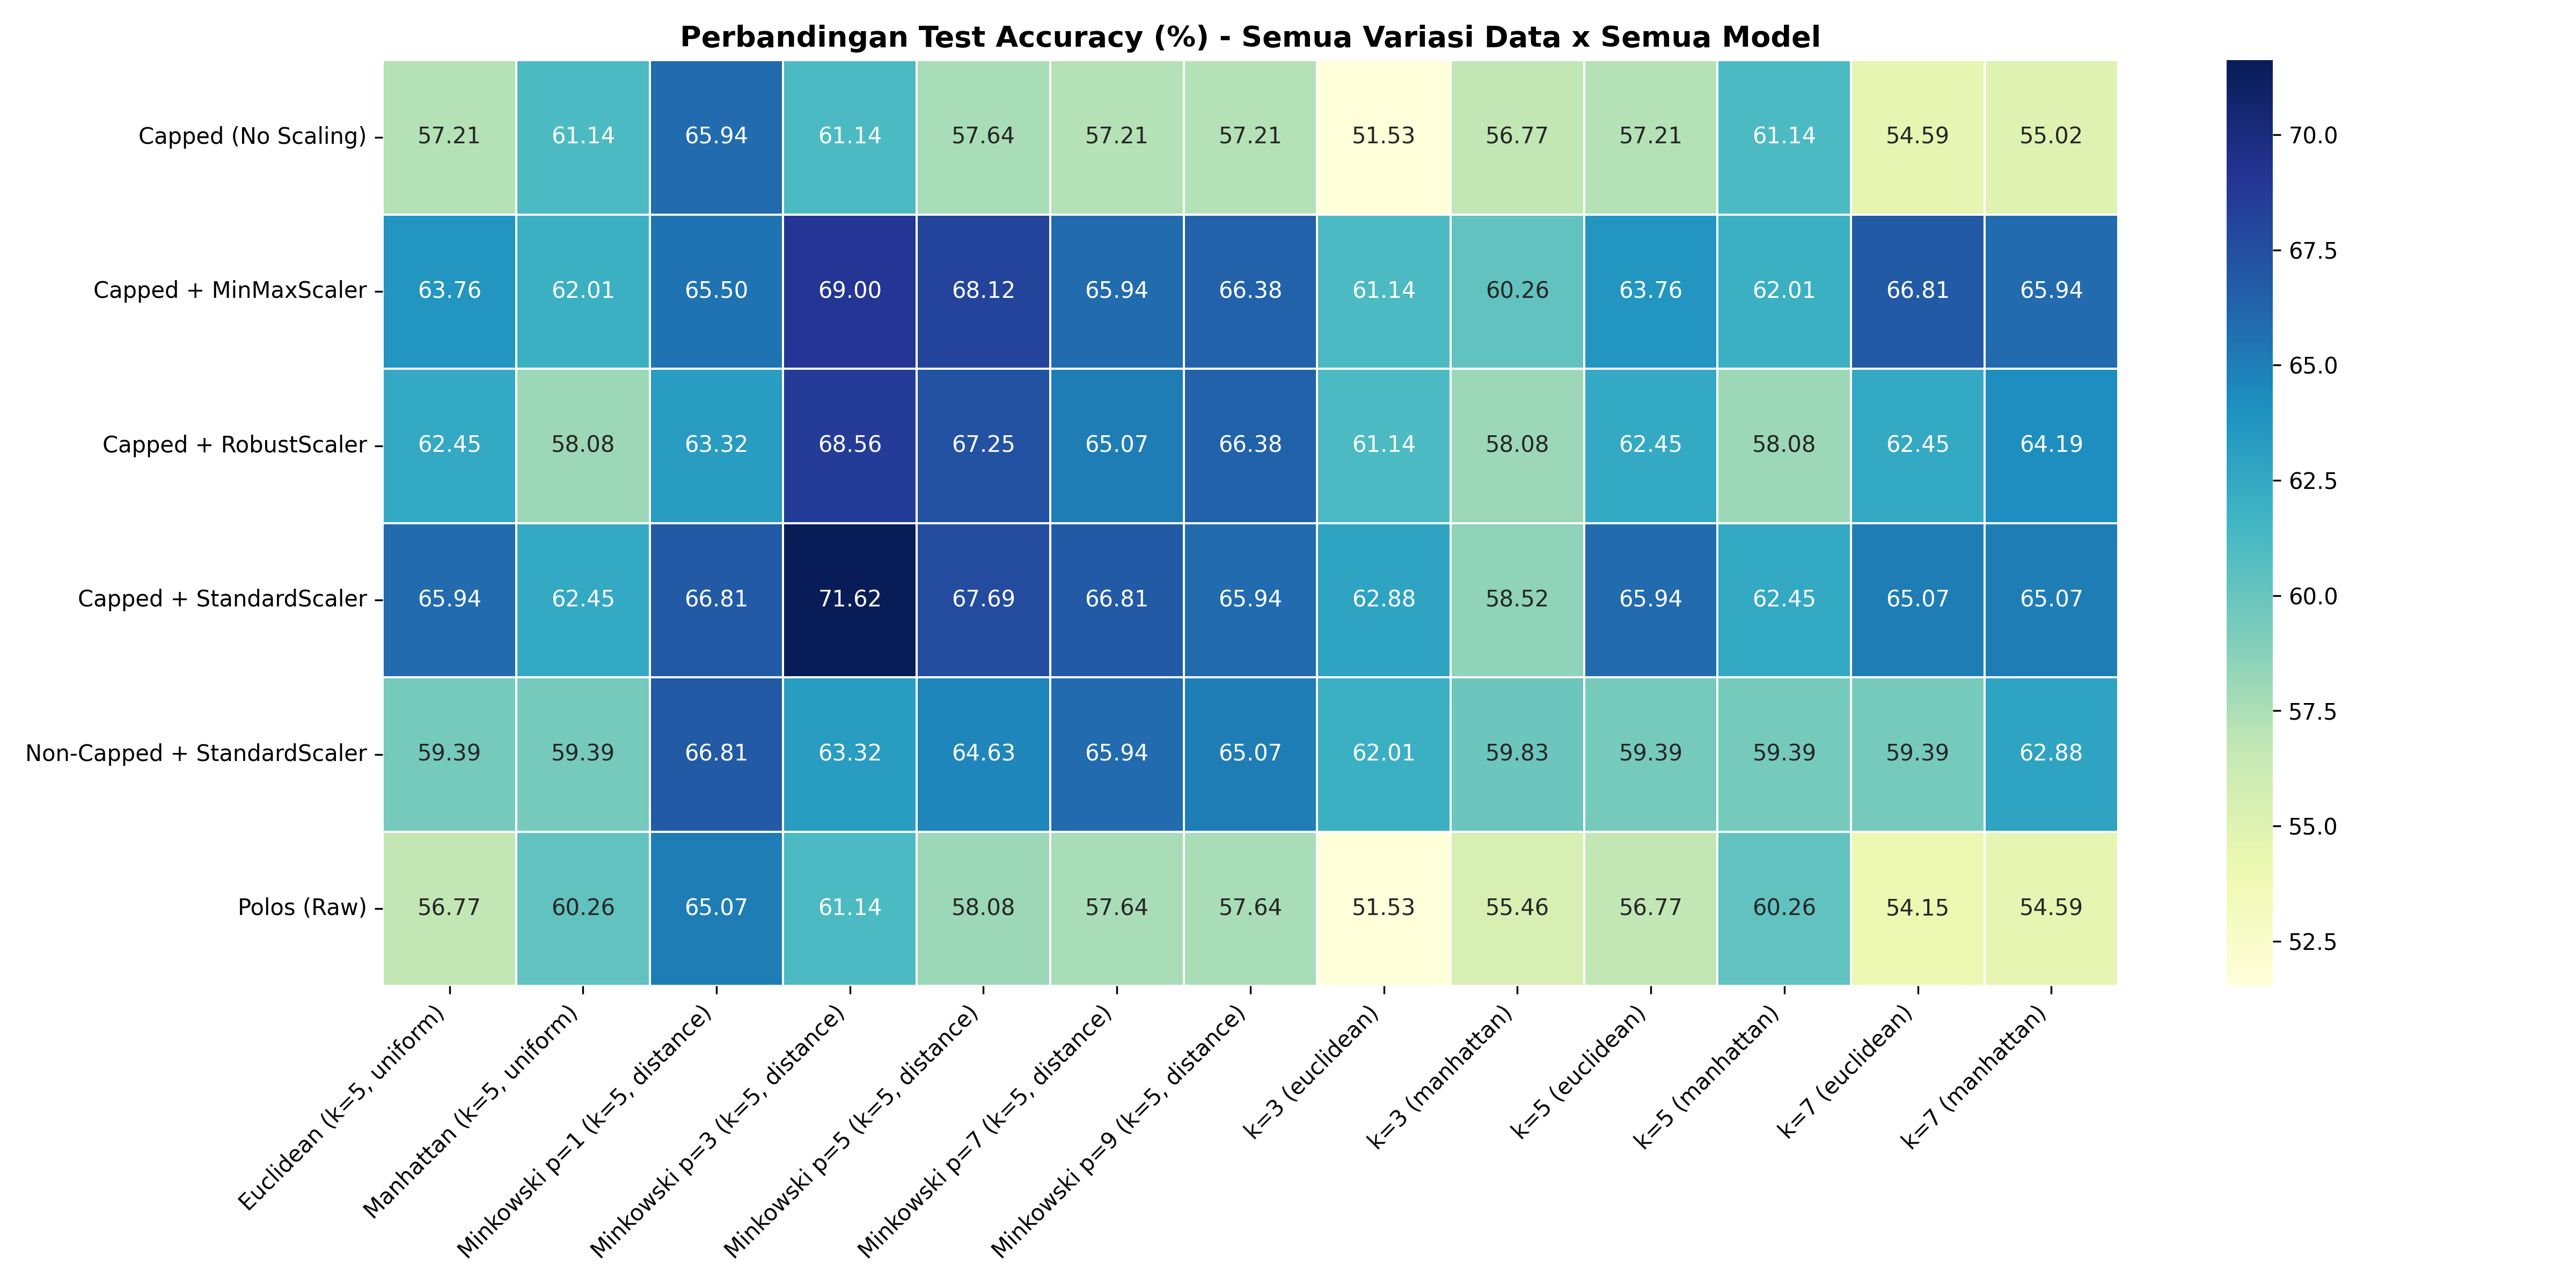

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**
1. Perbedaan dalam tune model knn dapat jauh meningkatkan akurasi model
2. Diperlukan pengamatan dan riset yang tajam untuk tahu fitur mana yang benar benar membantu model, mana yang hanya noise
3. Outlier sangat penting diatasi untuk menghindari model terlalu belajar hal ekstrim yang hanya sebuah pengecualian bukan pola
4. Scaling sangat bermanfaat dilakukan untuk menghindari bias pada fitur dengan nilai besar
5. Tahap awal yaitu eksplorasi sangat bermanfaat untuk memutuskan langkah selanjutnya dalam processing data

**Saran**
1. Bisa dilakukan lebih banyak kombinasi fitur untuk di drop untuk menemukan nilai akurasi maksimum yang bisa diraih knn dan menentukan bahwa fitur yang dipilih benar benar optimal
2. Perlu penanganan lebih untuk kelompok quality yang datanya sedikit seperti 1,2 dll agar model juga bisa memprediksi quality alcohol dengan baik di semua quality
